In [348]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

In [349]:
path = "../dataset/AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"
df = pd.read_csv(path)

In [350]:

# Compute derived columns
df['arrival_time'] = df['end_timestamp'] - df['duration']
df.sort_values(by='arrival_time', inplace=True)
hour_trace = 4
df['trace_id'] = (df['arrival_time'] // (hour_trace * 3600)).astype(int)
df['arrival_time_norm'] = df['arrival_time'] - (df['trace_id'] * hour_trace * 3600)

In [351]:
# Categories (min_req, max_req, num_func)
categories = [
    (90, 200, 2, 1, 2),     # Category 1: CoV in (1, 2)
    (80, 180, 3, 2, 3),    # Category 2: CoV in (2, 3)
    (120, 250,2, 3, 3.5)     # Category 3: CoV in (3, 4)
]

min_count = 2
best_groups = []

for cat_idx, (min_req, max_req, num_func, cov_min, cov_max) in enumerate(categories):
    best_score = -1
    best_group = None

    for trace_id in df['trace_id'].unique():
        trace = df[df['trace_id'] == trace_id]
        func_counts = trace['func'].value_counts()
        candidate_funcs = func_counts[
            (func_counts >= min_req) & (func_counts <= max_req)
        ].index.tolist()
        
        if len(candidate_funcs) < num_func:
            continue

        for funcs in combinations(candidate_funcs, num_func):
            covs = []
            valid = True

            for f in funcs:
                times = trace[trace['func'] == f]['arrival_time_norm'].sort_values().values
                if len(times) < 2:
                    valid = False
                    break
                gaps = np.diff(times)
                if len(gaps) < min_count or np.mean(gaps) == 0:
                    valid = False
                    break
                cov = np.std(gaps) / np.mean(gaps)
                covs.append(cov)

            if not valid:
                continue

            avg_cov = np.mean(covs)

            # Apply category-specific CoV condition
            if cov_min < avg_cov < cov_max and avg_cov > best_score:
                best_score = avg_cov
                best_group = {
                    'category': cat_idx + 1,
                    'trace_id': trace_id,
                    'functions': list(funcs),
                    'avg_cov': avg_cov
                }

    if best_group:
        best_groups.append(best_group)

# Final result
result_df = pd.DataFrame(best_groups)
print(result_df)


   category  trace_id                                          functions  \
0         1        57  [2055fbe5079ed7985f3c32f5c1dab88ca19000a18a096...   
1         2        71  [e5298aafdbabecd1465ab0eeb24d7633ac7de0284f7ee...   
2         3        74  [9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1f...   

    avg_cov  
0  1.980068  
1  2.998091  
2  3.485361  


/tmp/ipykernel_910114/4029340866.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


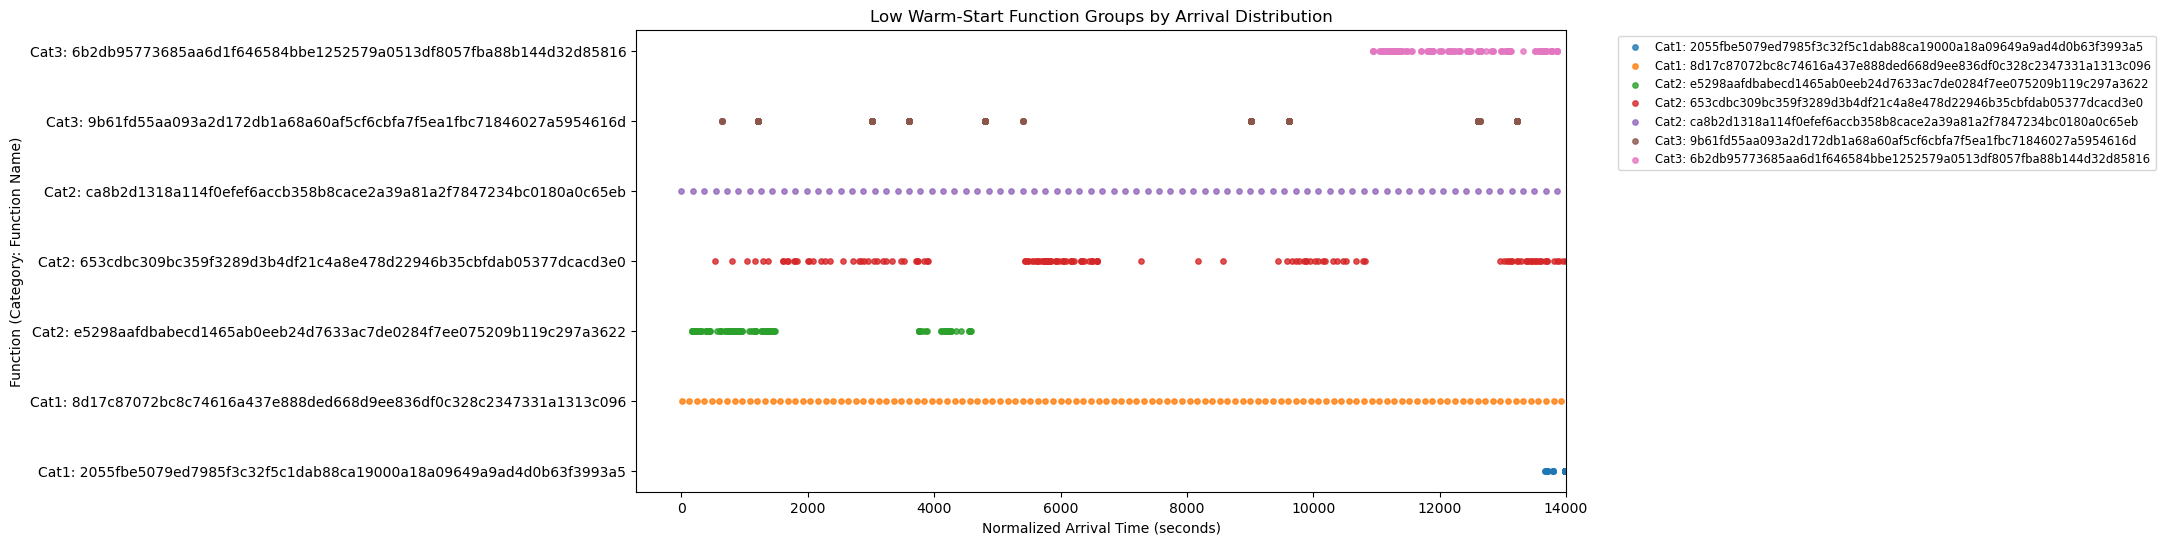

In [352]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

all_funcs = []
all_func_colors = {}
colors = plt.cm.tab10.colors
color_idx = 0

for _, entry in result_df.iterrows():
    trace_id = entry['trace_id']
    cat = entry['category']
    # if cat != 3:
    #     continue
    funcs = entry['functions']
    cat_color = colors[cat % len(colors)]
    for func in funcs:
        func_label = f"Cat{cat}: {func}"
        all_funcs.append(func_label)
        all_func_colors[func_label] = colors[color_idx % len(colors)]
        color_idx += 1
        func_df = df[(df['trace_id'] == trace_id) & (df['func'] == func)]
        plt.scatter(
            func_df['arrival_time_norm'],
            [func_label] * len(func_df),
            s=15,
            color=all_func_colors[func_label],
            label=func_label,
            alpha=0.8
        )


# Optional: Set max x-axis range
plt.xlim(right=14000)

# Deduplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.xlabel("Normalized Arrival Time (seconds)")
plt.ylabel("Function (Category: Function Name)")
plt.title("Low Warm-Start Function Groups by Arrival Distribution")
plt.tight_layout()
plt.show()


In [353]:
data = ['alexnet', 'efficientnet', 'bert', 'distilgpt2', 'resnet50', 'googlenet', 'inception']
i = 0 
res = []
name_header = ['func','trace_id','category_id','id','memory','file_path']
for l in best_groups:
    total_subset = len(l['functions'])
    
    for k in range(0,total_subset):
        temp = []
        trace_id = l['trace_id']
        category_id = l['category']
        func = data[i]
        memory = 1024
        file_path = data[i]+".py"
        id_val = l['functions'][k]
        i += 1
        res.append([func, trace_id, category_id, id_val, memory, file_path])

res_df = pd.DataFrame(res,columns=name_header)
func_dict = res_df.set_index('id')['func'].to_dict()
func_dict

{'2055fbe5079ed7985f3c32f5c1dab88ca19000a18a09649a9ad4d0b63f3993a5': 'alexnet',
 '8d17c87072bc8c74616a437e888ded668d9ee836df0c328c2347331a1313c096': 'efficientnet',
 'e5298aafdbabecd1465ab0eeb24d7633ac7de0284f7ee075209b119c297a3622': 'bert',
 '653cdbc309bc359f3289d3b4df21c4a8e478d22946b35cbfdab05377dcacd3e0': 'distilgpt2',
 'ca8b2d1318a114f0efef6accb358b8cace2a39a81a2f7847234bc0180a0c65eb': 'resnet50',
 '9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1fbc71846027a5954616d': 'googlenet',
 '6b2db95773685aa6d1f646584bbe1252579a0513df8057fba88b144d32d85816': 'inception'}

In [354]:
best_df_list = []

for _, entry in result_df.iterrows():
    trace_id = entry['trace_id']
    funcs = entry['functions']
    filtered = df[(df['trace_id'] == trace_id) & (df['func'].isin(funcs))]
    best_df_list.append(filtered)

# Concatenate all the filtered DataFrames
best_df = pd.concat(best_df_list, ignore_index=True)

# Optional: Sort by trace_id and arrival_time_norm for convenience
best_df = best_df.sort_values(by=['trace_id', 'func', 'arrival_time_norm']).reset_index(drop=True)

# Corrected normalization of arrival_time (if needed again)
best_df['arrival_time'] = best_df['arrival_time_norm']




In [355]:
best_df['func_id'] = best_df['func'].map(func_dict)
best_df

,app,func,end_timestamp,duration,arrival_time,trace_id,arrival_time_norm,func_id
0,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,2055fbe5079ed7985f3c32f5c1dab88ca19000a18a0964...,8.344724e+05,11.559,13660.813478,57,13660.813478,alexnet
1,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,2055fbe5079ed7985f3c32f5c1dab88ca19000a18a0964...,8.344780e+05,5.902,13672.088185,57,13672.088185,alexnet
2,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,2055fbe5079ed7985f3c32f5c1dab88ca19000a18a0964...,8.345002e+05,5.285,13694.887958,57,13694.887958,alexnet
3,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,2055fbe5079ed7985f3c32f5c1dab88ca19000a18a0964...,8.345052e+05,0.531,13704.661855,57,13704.661855,alexnet
4,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,2055fbe5079ed7985f3c32f5c1dab88ca19000a18a0964...,8.345052e+05,0.541,13704.665024,57,13704.665024,alexnet
...,...,...,...,...,...,...,...,...
919,734272c01926d19690e5ec308bab64ef97950b75b1c758...,9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1fb...,1.078820e+06,0.266,13219.733552,74,13219.733552,googlenet
920,734272c01926d19690e5ec308bab64ef97950b75b1c758...,9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1fb...,1.078820e+06,0.271,13219.734080,74,13219.734080,googlenet
921,734272c01926d19690e5ec308bab64ef97950b75b1c758...,9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1fb...,1.078820e+06,0.208,13219.734479,74,13219.734479,googlenet
922,734272c01926d19690e5ec308bab64ef97950b75b1c758...,9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1fb...,1.078820e+06,0.202,13219.734497,74,13219.734497,googlenet


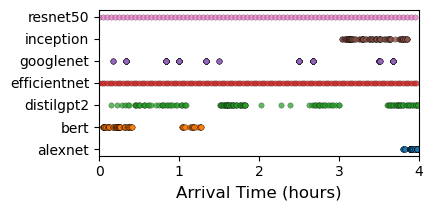

In [358]:
import matplotlib.pyplot as plt
import itertools

# Convert seconds to hours for x-axis
best_df['arrival_time_hr'] = best_df['arrival_time'] / 3600.0

# Marker styles to cycle through
markers = itertools.cycle(('o', 's', 'D', '^', 'v', 'P', '*'))

plt.figure(figsize=(4.5, 2.2))

# Plot each function group with style
for func_id, group in best_df.groupby('func_id'):
    plt.scatter(
        group['arrival_time_hr'],
        [func_id]*len(group),
        s=15,
        alpha=0.75,
        edgecolors='k',
        linewidths=0.2
    )

plt.xlabel("Arrival Time (hours)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 4)
# plt.grid(True, linestyle='--', linewidth=0.4)
plt.tight_layout()
plt.savefig("graphs_images/normal_dataset_graph.png", dpi=300, bbox_inches='tight')
plt.show()


In [347]:
category_counts = best_df['func_id'].value_counts().sort_index()
category_counts

func_id
alexnet       121
bert          105
distilgpt2     80
googlenet     195
inception     240
resnet50      210
Name: count, dtype: int64

In [359]:
best_df = best_df.sort_values(by='arrival_time', ascending=True)

res_df.to_csv('../dataset/normal_gen_functions.csv', index=False)
best_df.to_csv('../dataset/normal_gen_df.csv', index=False)

In [360]:
best_df

,app,func,end_timestamp,duration,arrival_time,trace_id,arrival_time_norm,func_id,arrival_time_hr
386,68d84244f6a3c212c69884d292b01a04ade8573f6c7b74...,ca8b2d1318a114f0efef6accb358b8cace2a39a81a2f78...,1.022400e+06,0.109,0.009291,71,0.009291,resnet50,0.000003
121,f8a0e46efc7202b8d1ce896a4e0919f3b3e6d496c244a3...,8d17c87072bc8c74616a437e888ded668d9ee836df0c32...,8.208019e+05,0.034,1.823197,57,1.823197,efficientnet,0.000506
122,f8a0e46efc7202b8d1ce896a4e0919f3b3e6d496c244a3...,8d17c87072bc8c74616a437e888ded668d9ee836df0c32...,8.209220e+05,0.019,121.971655,57,121.971655,efficientnet,0.033881
466,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,e5298aafdbabecd1465ab0eeb24d7633ac7de0284f7ee0...,1.022562e+06,0.012,162.095106,71,162.095106,bert,0.045026
467,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,e5298aafdbabecd1465ab0eeb24d7633ac7de0284f7ee0...,1.022563e+06,0.010,162.653235,71,162.653235,bert,0.045181
...,...,...,...,...,...,...,...,...,...
119,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,2055fbe5079ed7985f3c32f5c1dab88ca19000a18a0964...,8.351204e+05,2.961,14317.424993,57,14317.424993,alexnet,3.977062
120,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,2055fbe5079ed7985f3c32f5c1dab88ca19000a18a0964...,8.351204e+05,2.671,14317.724024,57,14317.724024,alexnet,3.977146
383,c8c43e1a911f29e5506460a2fbef61ff39723d672f3b3b...,653cdbc309bc359f3289d3b4df21c4a8e478d22946b35c...,1.036748e+06,3.414,14344.815443,71,14344.815443,distilgpt2,3.984671
384,c8c43e1a911f29e5506460a2fbef61ff39723d672f3b3b...,653cdbc309bc359f3289d3b4df21c4a8e478d22946b35c...,1.036778e+06,17.575,14360.330985,71,14360.330985,distilgpt2,3.988981
